## Tutorial: Membrane mechanics

This tutorial uses `triangulax` to study the mechanics of membranes. We numerically represent a membrane as a triangular mesh, and finds its mechanically balanced configuration by energy minimization, using automatic differentiation to calculate energy gradients.

In [1]:
import numpy as np
from scipy import sparse, optimize
import matplotlib.pyplot as plt
import meshplot

import igl

In [2]:
import jax.numpy as jnp
import jax

In [3]:
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", True)

In [4]:
import lineax
import optimistix

In [5]:
from triangulax import trigonometry as trig
from triangulax import geometry as geom
from triangulax import adjacency as adj
from triangulax import linops as lin
from triangulax.triangular import TriMesh
from triangulax.mesh import HeMesh, GeomMesh
from triangulax import linops
from triangulax import algorithms as algo

## Computing the mean curvature

The mean curvature of a surface (see [wikipedia](https://en.wikipedia.org/wiki/Differential_geometry_of_surfaces), and [Crane, Chpt. 5](https://www.cs.cmu.edu/~kmcrane/Projects/DDG/paper.pdf))
can be computed from the Laplace operator, applied to the vertex positions $\mathbf{v}$ as $\Delta\mathbf{v} = 2H\mathbf{n}$, where $\mathbf{n}$ is the surface normal. To compute the curvature $H$ numerically, one can also use the _dihedral angles_ $\theta_{ij}$ of each edge $ij$: the angles between the normal vectors of adjacent triangles. The mean curvature at vertex $i$ can be approximated by
$$H_i = \frac{1}{4a_i} \sum_{j\sim i} \ell_{ij} \theta_{ij} $$
where the sum is over all $j$ neighboring $i$, and $a_i$ is the barycentric area around vertex $i$. This discretization turns out to be more robust numerically, and is already implemented in the `geometry` module.

In [69]:
# let's look at a torus which has varying mean curvature

torus = TriMesh.read_obj("../test_meshes/torus.obj",dim =3)
hemesh_torus = HeMesh.from_triangles(torus.vertices.shape[0], torus.faces)

H_torus_lap = geom.get_mean_curvature_laplace(torus.vertices, hemesh_torus, normalize=True)
H_torus_dihed = geom.get_mean_curvature_dihedral(torus.vertices, hemesh_torus, normalize=True)

_, _, k1_t, k2_t, _ = igl.principal_curvature(torus.vertices.astype(np.float64), hemesh_torus.faces)
H_torus_dihed_igl = (k1_t + k2_t) / 2


  o Torus


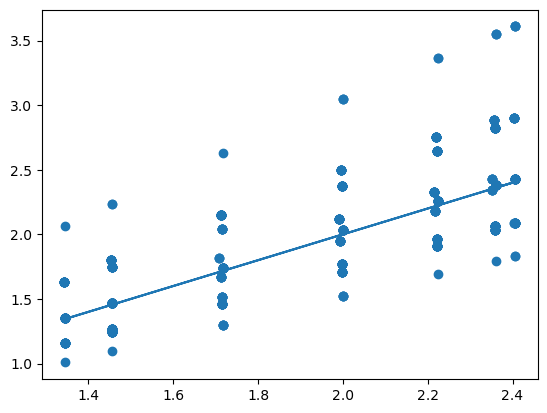

In [70]:
plt.scatter(H_torus_lap, H_torus_dihed)
plt.plot(H_torus_lap, H_torus_lap)


In [ ]:
dihedral_angles = geom.get_dihedral_angles(torus.vertices, hemesh_torus)
edge_lengths = geom.get_he_length(torus.vertices, hemesh_torus)

barycentric_areas = geom.get_barycentric_cell_areas(torus.vertices, hemesh_torus)

H_dihedral = 1/4 * adj.sum_he_to_vertex_incoming(hemesh_torus, dihedral_angles*edge_lengths) #/ barycentric_areas


In [ ]:
def sum_face_to_vertex(hemesh, f_field):
    out_shape = (hemesh.n_vertices,) + f_field.shape[1:]
    v_field = jnp.zeros(out_shape, dtype=f_field.dtype)

    return v_field

In [73]:
voronoi_areas = geom.get_voronoi_areas(torus.vertices, hemesh_torus)
barycentric_areas = adj.sum_face_to_vertex(hemesh_torus, geom.get_triangle_areas(torus.vertices, hemesh_torus)) / 3


In [75]:
jnp.corrcoef(voronoi_areas, barycentric_areas)[0,1]

Array(0.75766347, dtype=float64)

(np.float64(0.012526973519759777),
 np.float64(0.02118819260173175),
 np.float64(0.007494206881595273),
 np.float64(0.02879906913864483))

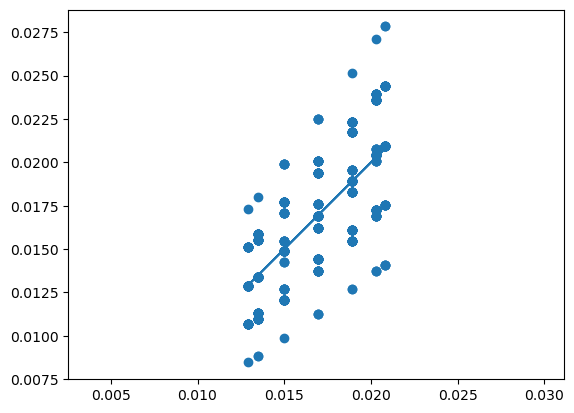

In [74]:
plt.plot(voronoi_areas, voronoi_areas)
plt.scatter(voronoi_areas, barycentric_areas)
plt.axis("equal")

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

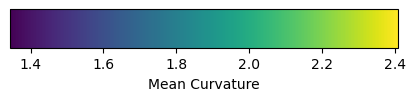

In [68]:
#meshplot.plot(torus.vertices, hemesh_torus.faces , np.array(H_torus), shading={"wireframe": True})

meshplot.plot(torus.vertices, hemesh_torus.faces , np.array(H_torus_dihed_igl), shading={"wireframe": True})

#meshplot.plot(torus.vertices, hemesh_torus.faces , np.array(H_torus_dihed), shading={"wireframe": True})

# add a colorbar
fig, ax = plt.subplots(figsize=(5, 0.5))
sm = plt.cm.ScalarMappable(cmap='viridis',norm=plt.Normalize(vmin=np.array(H_torus_lap).min(),
                                                             vmax=np.array(H_torus_lap).max()))
cbar = fig.colorbar(sm, cax=ax, orientation='horizontal')
cbar.set_label('Mean Curvature')
plt.show()


## Minimal surfaces

As a first example, let's consider a membrane $\mathcal{M}$ whose energy is dominated by surface tension, so the energy is proportional to the membrane area $E_A = \int_{\mathcal{M}} dA$. Note that moving vertices _within_ the plane of the mesh does not change the total area/energy (physically, this is because membranes are fluid in-plane, rather than thin elastic sheets). This has important numerical consequences: we will want to arrange the mesh vertices so as to avoid a highly distorted mesh with very stretched triangles.

A nice algorithm by [Pinkall and Poitier](https://projecteuclid.org/journalArticle/Download?urlId=em%2F1062620735) takes care of this problem. It uses the discretized Laplacian which we already used in the previous notebook for the heat equation. 
The idea is that to minimize the area, the position of a vertex $\mathbf{v}_i$ should be equal to the (geometry-weighted) average of its neighbors, and therefore $\Delta \mathbf{v}_i = 0$. The resulting iterative algorithm works as follows.

1. Given the vertex-positions $\mathbf{v}_i^{(t)}$ at step $t$, compute the cotan-Laplacian matrix $\Delta^{(t)}_{ij}$
2. Solve $\Delta^{(t)}_{ij} \cdot \mathbf{v}_i^{(t+1)} =0$, subject to fixed boundary conditions.

  o flat_tri_ecmc


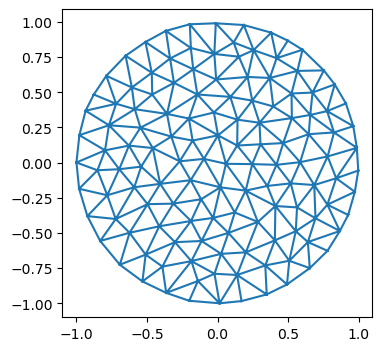

In [8]:
# let's load a simple test mesh

trimesh = TriMesh.read_obj("../test_meshes/disk.obj", dim=3)
hemesh = HeMesh.from_triangles(trimesh.vertices.shape[0], trimesh.faces)

fig = plt.figure(figsize=(4,4))
plt.triplot(*trimesh.vertices[:,:2].T, trimesh.faces)
plt.axis("equal");

In [9]:
# let's impose some boundary conditions on the disk mesh - think of this as finding the shape of a "soap film"
# with a given boundary curve.

bdry_verts = np.where(hemesh.is_bdry)[0]
interior_verts = np.where(~hemesh.is_bdry)[0]

phi_bdry = np.atan2(*trimesh.vertices[bdry_verts, :2].T)
h = 0.5*np.sin(2*phi_bdry)
bdry_pos = np.array(trimesh.vertices[bdry_verts, :])
bdry_pos[:, -1] = h

vertices_bdry_imposed = np.copy(trimesh.vertices)
vertices_bdry_imposed[bdry_verts] = bdry_pos

In [10]:
# the non-optimized membrane is pretty creased

meshplot.plot(vertices_bdry_imposed, hemesh.faces, shading={"wireframe":False}, return_plot=True)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.001874…

In [11]:
# compute the area of the initial configuration - this is the energy we will minimize
initial_area = geom.get_area(vertices_bdry_imposed, hemesh)
print(f"Initial area: {initial_area:.4f}")

Initial area: 4.3650


In [12]:
# let's check the cotan-Laplacian gives us the area via A = 1/2 * v^T L v, where v are the vertex positions

L = linops.cotan_laplace_sparse(vertices_bdry_imposed, hemesh)
area_L = -jnp.diag(vertices_bdry_imposed.T.dot(L @ vertices_bdry_imposed)).sum() /2

print(f"Initial area from Laplace operator: {area_L:.4f}")

Initial area from Laplace operator: 4.3650


In [13]:
# Let's use the iterative Pinkall-Poitier method to find the mininum energy configuration.

vertices_iterated = [np.copy(vertices_bdry_imposed)] 

for t in range(10):
    L = linops.bcoo_to_scipy(linops.cotan_laplace_sparse(vertices_iterated[-1], hemesh)) # compute Laplace matrix

    # impose boundary conditions by splitting the Laplace matrix into interior and boundary vertices
    L_ii = L[interior_verts, :][:, interior_verts] 
    L_ib = L[interior_verts, :][:, bdry_verts]
    bcs = vertices_bdry_imposed[bdry_verts,:]
    
    new_vertices = np.zeros_like(vertices_iterated[-1])
    new_vertices[bdry_verts] = bcs

    solution = np.stack([sparse.linalg.spsolve(-L_ii, L_ib.dot(bc)) for bc in bcs.T], axis=-1)
    # iterate over x/y/z coordinates
    new_vertices[interior_verts] = solution
    vertices_iterated.append(new_vertices)

In [14]:
# as a result of the optimization, we get an area-minimizing "Pringles" surface

meshplot.plot(vertices_iterated[-1], hemesh.faces, shading={"wireframe":True}, return_plot=True)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.001874…

In [15]:
final_area = geom.get_area(vertices_iterated[-1], hemesh)
print(f"Initial area: {initial_area:.4f}", f"Final area: {final_area:.4f}")

Initial area: 4.3650 Final area: 3.7981


In [16]:
# the gradient of the area is very small after optimization:   

(jnp.linalg.norm(jax.grad(geom.get_area)(vertices_iterated[0], hemesh), axis=-1)[interior_verts].mean(),
 jnp.linalg.norm(jax.grad(geom.get_area)(vertices_iterated[-1], hemesh), axis=-1)[interior_verts].mean())

(Array(0.06015605, dtype=float64), Array(0.00068703, dtype=float64))

In [17]:
# the mean curvature is also very small after optimization, as expected for a minimal surface:
H_laplace = get_mean_curvature_laplace(vertices_iterated[-1], hemesh)
jnp.abs(H_laplace).mean()


Array(0.06984846, dtype=float64)

### Helfrich energy

Next, let's consider a membrane for which the surface tension is negligible. This is the case for many of the lipid bilayer membranes that make up the cell and its interior organelles. Instead, the energy is dominated by _bending_.

The _Helfrich energy_ is an elegant, geometric model of bending energy. It uses the mean and Gaussian curvatures $H, K$ of the surface $\mathcal{M}$. The energy reads:

$$E_H  =\int dA \left( \frac{\kappa_H}{2}(H-H_0)^2 + \kappa_G K \right) $$

If the surface is closed, the $\int K$-term is a topological invariant and can be dropped (and we will do so here). 
A nonzero _spontaneous curvature_ $H_0$ means that the membrane "prefers" to be curved; this can result, for instance, from molecules that bind to the membrane.

In [18]:
# let's load a sphere as a test mesh for the Helfrich energy

trimesh = TriMesh.read_obj("../test_meshes/sphere_fine.obj", dim=3) # sphere_fine sphere

trimesh.vertices -= trimesh.vertices.mean(axis=0)
trimesh.vertices = (trimesh.vertices.T / np.linalg.norm(trimesh.vertices, axis=1)).T

hemesh = HeMesh.from_triangles(trimesh.vertices.shape[0], trimesh.faces)

  o Icosphere


In [19]:
meshplot.plot(trimesh.vertices, hemesh.faces, shading={"wireframe":True})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

In [31]:
# let's define the discrete Helfrich energy.

@jax.jit
def get_helfrich_energy(vertices, args):
    """Compute the discrete Helfrich energy of a triangulated surface. args = (hemesh, H0, kappa)"""
    hemesh, H0, kappa = args
    H = geom.get_mean_curvature_dihedral(vertices, hemesh)
    #H = get_mean_curvature_laplace(vertices, hemesh)
    cell_areas = geom.get_barycentric_cell_areas(vertices, hemesh)
    return (kappa/2) * ((H - H0) **2 * cell_areas).sum()

In [32]:
# let's check the mean-curvature of the sphere using the Laplace operator - this should be constant across all vertices

vertices = trimesh.vertices
H_laplace = get_mean_curvature_laplace(vertices, hemesh)
H_dihedral = geom.get_mean_curvature_dihedral(vertices, hemesh)

# let's compute the radius of the sphere:
R = jnp.linalg.norm(vertices-vertices.mean(axis=0), axis=-1).mean()
print("H (Laplace)", H_laplace.mean(), "H - 1/R:", jnp.abs(H_laplace - 1/R).mean())
print("H (Dihedral)", H_dihedral.mean(), "H - 1/R:", jnp.abs(H_dihedral - 1/R).mean())

H (Laplace) 1.0000076108652165 H - 1/R: 7.6108652156698455e-06
H (Dihedral) 1.0044138499642183 H - 1/R: 0.004413849964217461


In [33]:
args = (hemesh, 0, 1)
# exact helfrich for a sphere is 2*pi, here smaller due to discretization error. The energy is scale invariant.
get_helfrich_energy(trimesh.vertices, args), get_helfrich_energy(2*trimesh.vertices, args)

(Array(6.29466847, dtype=float64), Array(6.29466847, dtype=float64))

In [34]:
# now, let's deform the sphere and minimize the Helfrich energy to find the equilibrium shape.

deformed_vertices = trimesh.vertices.at[:, 1].add(0.5*trimesh.vertices[:, 1]**3)
deformed_vertices = trimesh.vertices.at[:, 2].add(0.5*trimesh.vertices[:, 0]**3)

print("Minimum vs deformed energy:", get_helfrich_energy(trimesh.vertices, args),
                                     get_helfrich_energy(deformed_vertices, args))

Minimum vs deformed energy: 6.294668468631172 7.159011639563514


In [35]:
meshplot.plot(deformed_vertices, hemesh.faces, shading={"wireframe":True})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

In [36]:
# we can compute the energy gradient

grad = jax.grad(get_helfrich_energy)(deformed_vertices, args)
normal = geom.get_vertex_normals(deformed_vertices, hemesh)
grad_norm = jnp.linalg.norm(grad, axis=-1)

(jnp.abs(jnp.linalg.vecdot(grad, normal)) / grad_norm).mean() # gradient is along normal

Array(0.98613633, dtype=float64)

In [39]:
import jax.test_util

In [43]:
jax.test_util.check_grads(get_helfrich_energy, (deformed_vertices, args), order=1, modes=('fwd', 'rev'),
                          atol=None, rtol=None, eps=None)

TypeError: primal and tangent arguments to jax.jvp do not match; dtypes must be equal, or in case of int/bool primal dtype the tangent dtype must be float0.Got primal dtype int64 and so expected tangent dtype [('float0', 'V')], but got tangent dtype int64 instead.

#### Nonlinear minimization

To minimize the energy, we can use one of many non-linear minimization algorithms, all of which use the gradient $\nabla E_H$ which we can compute using JAX. Here, we use the JAX-based optimization library `optimistix`.

In [26]:
solver = optimistix.BFGS(rtol=1e-8, atol=1e-8)

y0 = deformed_vertices
args = (hemesh, 0, 1) 

sol = optimistix.minimise(get_helfrich_energy, solver, y0, args, max_steps=2000, throw=False)
vertices_final = sol.value

In [27]:
print("Initial/final/minimal energy:", get_helfrich_energy(y0, args),
                                       get_helfrich_energy(sol.value, args),
                                       get_helfrich_energy(trimesh.vertices, args))

Initial/final/minimal energy: 7.064731463226383 5.66644072931026 6.2531824128234526


In [28]:
# displacement from initial condition.

jnp.linalg.norm(y0-sol.value, axis=-1).mean(), jnp.linalg.norm(y0-trimesh.vertices, axis=-1).mean() 

(Array(0.04425016, dtype=float64), Array(0.12507872, dtype=float64))

In [29]:
# after minimization, the deviation from being a perfect sphere is fairly low

center = jnp.average(vertices_final, weights=geom.get_barycentric_cell_areas(vertices_final, hemesh), axis=0)
Rs =  jnp.linalg.norm(vertices_final - center, axis=1)

Rs.std() / Rs.mean()

Array(0.04188804, dtype=float64)

In [30]:
p = meshplot.plot(y0, hemesh.faces, np.array(grad_norm),shading={"wireframe":True}, return_plot=True)
p.add_mesh(sol.value + np.array([0, 0, 3]), hemesh.faces, shading={"wireframe":True})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

1

## Constrained minimization using Penalty and Augmented Lagrangian methods

Much of the physics of membranes arises from balancing the Helfrich bending energy with constraints on the volume $V$ and area $A$ of the membrane. For simplicity, we softly enforce these contrstraints with quadratic penalty terms in the energy:
$$E_P =  \mu_V(V-V_0)^2/(2V_0) + \mu_A(A-A_0)^2/(2A_0)$$


In [238]:
trimesh = TriMesh.read_obj("../test_meshes/sphere_fine.obj", dim=3) # let's load a finer mesh
trimesh.vertices -= trimesh.vertices.mean(axis=0)
trimesh.vertices = (trimesh.vertices.T / np.linalg.norm(trimesh.vertices, axis=1)).T

hemesh = HeMesh.from_triangles(trimesh.vertices.shape[0], trimesh.faces)

  o Icosphere


In [239]:
# verify volume and area on the sphere mesh
A_sphere = geom.get_area(trimesh.vertices, hemesh)
V_sphere = geom.get_volume(trimesh.vertices, hemesh)
print(f"Sphere area: {A_sphere:.4f} (exact 4π = {4*jnp.pi:.4f})")
print(f"Sphere volume: {V_sphere:.4f} (exact 4π/3 = {4*jnp.pi/3:.4f})")

Sphere area: 12.5062 (exact 4π = 12.5664)
Sphere volume: 4.1527 (exact 4π/3 = 4.1888)


In [240]:
@jax.jit
def get_helfrich_energy_with_penalty(vertices, args):
    """Compute the discrete Helfrich energy of a triangulated surface with a penalty method.
    args = (hemesh, H0, kappa, mu_A, mu_V, A0, V0)"""
    hemesh, H0, kappa, mu_A, mu_V, A0, V0 = args
    E = get_helfrich_energy(vertices, (hemesh, H0, kappa))
    contraint_area = mu_A/2 * (geom.get_area(vertices, hemesh) - A0)**2/A0
    constraint_volume = mu_V/2 *(geom.get_volume(vertices, hemesh) - V0)**2 / V0**2
    return E + contraint_area + contraint_area  + constraint_volume

In [275]:
A0 = geom.get_area(trimesh.vertices, hemesh)
V0 = 0.8 * geom.get_volume(trimesh.vertices, hemesh)
kappa, H0 = 1.0, 0.0
mu_A = 300.0
mu_V = 600.0
args = (hemesh, H0, kappa, mu_A, mu_V, A0, V0)

y0 = trimesh.vertices * np.array([0.95, 1.1, 0.95]) # let's start from a stretched configuration

In [299]:
solver = optimistix.LBFGS(rtol=1e-8, atol=1e-8,) #   learning_rate=0.001
sol = optimistix.minimise(get_helfrich_energy_with_penalty, solver, y0, args, max_steps=10000, throw=True)
vertices_final = sol.value

In [300]:
grad_norm = jnp.linalg.norm(jax.grad(get_helfrich_energy_with_penalty)(y0, args), axis=-1)

In [301]:
grad_norm.std() / grad_norm.mean()

Array(0.14677809, dtype=float64)

In [302]:
z = adj.get_coordination_number(hemesh)

In [303]:
grad_norm[z==5].mean(), grad_norm[z==6].mean()

(Array(0.24017291, dtype=float64), Array(0.82794438, dtype=float64))

In [304]:
geom.get_area(vertices_final, hemesh)/A0, geom.get_volume(vertices_final, hemesh)/V0

(Array(0.99524543, dtype=float64), Array(1.02675628, dtype=float64))

In [305]:
p = meshplot.plot(y0, hemesh.faces, np.array(grad_norm),
                  shading={"wireframe":True}, return_plot=True)

p.add_mesh(sol.value + np.array([3, 0, 0]), hemesh.faces, shading={"wireframe":True})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

1

### Regularization tangential mesh motion

If you play around with the above code, you will notice that it is rather unstable. The reason is the _reparametrization_ invariance of the Helfrich energy we already alluded to - moving vertices in the local tangent plane does not change the energy. Therefore, the triangles of the mesh can easily degenerate during energy minimization, leading to numerical instability. To avoid this, we can add a smoothing step that repositions the vertices tangentially to improve mesh quality between energy minimization steps.

In [306]:
solver = optimistix.LBFGS(rtol=1e-8, atol=1e-8,) #   learning_rate=0.001

vertices_smoothed = y0
n_iterations = 100
n_smoothing = 10
smoothing_step_size = 0.1
n_minimization = 50


for i in range(n_iterations):
    sol = optimistix.minimise(get_helfrich_energy_with_penalty, solver, vertices_smoothed, args,
    max_steps=n_minimization, throw=False)
    vertices_smoothed = sol.value
    for j in range(n_smoothing):
        vertices_smoothed = algo.smooth_vertices_laplacian(vertices_smoothed, hemesh, step_size=smoothing_step_size)


In [307]:
geom.get_area(vertices_smoothed, hemesh)/A0, geom.get_volume(vertices_smoothed, hemesh)/V0

(Array(0.96978456, dtype=float64), Array(0.99362936, dtype=float64))

In [308]:
p = meshplot.plot(y0, hemesh.faces, np.array(grad_norm),
                  shading={"wireframe":True}, return_plot=True)

p.add_mesh(vertices_smoothed + np.array([3, 0, 0]), hemesh.faces, shading={"wireframe":True})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

1

Tangential smoothing is the simplest example of a more general method in which one alternatingly minimizes the physical energy by moving vertices in the surface normal direction, and a parametrization pseudo-energy by moving vertices along the tangential directions.

More precisely, let $E_N$ be the physical energy (like the Helfrich bending energy), and let $E_T$ be a pseudo energy that penalizes poor mesh configurations. Note that $E_T$ should only depend on the in-plane shear of the mesh and not on bending to minimize overlap with the physical energy. A simple gradient-descent scheme reads like so:

$$\mathbf{v}_i^{(t+1)} = \mathbf{v}_i^{(t)} + \eta \left(P_{\mathbf{n}_i^{(t)}} \cdot \nabla E_N
 + (\mathbb{I}- P_{\mathbf{n}_i^{(t)}}) \cdot \nabla E_T)
\right) $$

where $P_\mathbf{n} = \mathbb{I} - \mathbf{n}\otimes \mathbf{n}$ is the projector on the normal $\mathbf{n}$


In [252]:
def get_neo_hookean_energy(deformation, mod_bulk, mod_shear):
    """Compute the neo-Hookean energy from Cauchy-Green deformation tensor.
    See https://en.wikipedia.org/wiki/Neo-Hookean_solid
    """
    I1 = jnp.trace(deformation)
    J = jnp.sqrt(jnp.linalg.det(deformation))
    return mod_shear/2*(I1 - 2 - 2*jnp.log(J)) + mod_bulk/2*(J-1)**2


def get_metric(vertices, hemesh):
    """Compute the metric tensor per triangle of a triangulated surface"""
    a, b, c = vertices[hemesh.faces.T]
    J = jnp.stack([b-a, c-a], axis=1)
    return jnp.einsum("vix,vjx->vij", J, J)

@jax.jit
def get_elastic_energy(vertices, args):
    """Compute the elastic energy of a triangulated surface. args = (hemesh, metric_orig, mod_bulk, mod_shear)"""
    hemesh, metric_orig, mod_bulk, mod_shear = args
    triangle_areas = geom.get_triangle_areas(vertices, hemesh)
    metric = get_metric(vertices, hemesh)
    deformation = jnp.einsum("vij,vjk->vik", jnp.linalg.inv(metric_orig), metric)
    energies = jax.vmap(get_neo_hookean_energy, in_axes=(0,None,None))(deformation, mod_bulk, mod_shear)
    return (triangle_areas*energies).sum()

In [253]:
# this is how the elastic energy penalizes deformation, expressed in terms of the deformation gradient F,
# so that F-I is the usual strain tensor.

s = -0.1 # dilation
t = 0. # shear

F = jnp.array([[1+s, t],[t, 1+s]])
g0 = jnp.eye(2)
g1 = F @ F.T
deformation = jnp.linalg.inv(g0) @ g1

get_neo_hookean_energy(jnp.eye(2), 1, 1), get_neo_hookean_energy(deformation, 0, 1)

(Array(0., dtype=float64), Array(0.02072103, dtype=float64))

In [254]:
A0 = geom.get_area(trimesh.vertices, hemesh)
V0 = 0.75 * geom.get_volume(trimesh.vertices, hemesh)
metric_orig = get_metric(trimesh.vertices, hemesh)

kappa, H0 = 1.0, 0.0
mu_A, mu_V = 300.0, 600.0
args_helfrich_penalty = (hemesh, H0, kappa, mu_A, mu_V, A0, V0)

mod_bulk, mod_shear = 0.0, 1.0
args_elastic = (hemesh, metric_orig, mod_bulk, mod_shear)

step_size = 0.01
n_iterations = 4

vertices_initial = trimesh.vertices * np.array([0.95, 1.1, 0.95]) # let's start from a stretched configuration

In [309]:
vertices_iterated = [vertices_initial]

for t in range(n_iterations):
    grad_helfrich = jax.grad(get_helfrich_energy_with_penalty)(vertices_iterated[-1], args_helfrich_penalty)
    grad_elastic = jax.grad(get_elastic_energy)(vertices_iterated[-1], args_elastic)
    normals = geom.get_vertex_normals(vertices_iterated[-1], hemesh)
    step = (jax.vmap(trig.project_out_vector)(grad_elastic, normals) +
            jax.vmap(trig.project_on_vector)(grad_helfrich, normals))
    vertices_iterated.append(vertices_iterated[-1] - step_size * step)

Invalid nan value encountered in the output of a jax.jit function. Calling the de-optimized version.
Invalid nan value encountered in the output of a jax.jit function. Calling the de-optimized version.
Invalid nan value encountered in the output of a jax.jit function. Calling the de-optimized version.
Invalid nan value encountered in the output of a jax.jit function. Calling the de-optimized version.


FloatingPointError: invalid value (nan) encountered in dot_general

In [ ]:
jnp.linalg.norm(vertices_iterated[-1] - vertices_iterated[0], axis=-1).mean()

Array(0.01900834, dtype=float64)

In [ ]:
# something is going wrong with the gradient of the Helfrich energy wtf

In [310]:
p = meshplot.plot(vertices_initial, hemesh.faces,
                  shading={"wireframe":True}, return_plot=True)

p.add_mesh(vertices_iterated[-1] + np.array([3, 0, 0]), hemesh.faces, shading={"wireframe":True})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

/Users/nc1333/miniforge3/envs/triangulax/lib/python3.14/site-packages/meshplot/Viewer.py:88: RuntimeWarning: invalid value encountered in add
  mean = ((ma - mi) / 2 + mi).tolist()
/Users/nc1333/miniforge3/envs/triangulax/lib/python3.14/site-packages/jupyter_client/session.py:727: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant: nan
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


1

In [ ]:
# looks like there is a strong discretization error in the gradient of the helricht energy
# at 5-fold vertices. this is not good.

### Augmented Lagrangian method

A more systematic way to include the area and volume constraints is via two Lagrange multipliers $\lambda, p$, surface tension and pressure:   

$$\mathcal{L} = E_H - \lambda (A-A_0) -p (V-V_0) $$

Minimization under the boundary constraint is equivalent to stationarity of the Lagrangian:

$$\nabla_\lambda \mathcal{L} = 0 \quad \mathrm{and} \quad \nabla_{\mathbf{v}} \mathcal{L} = 0 $$

Finding these stationary points - the aim of _numerical constrained minimization_ - can be quite challenging.
If the number of constraints (here, $2$) is small compared to the number of variables (here, $3\#\mathrm{vertices}$), _augmented Lagrangian methods_ are a suitable approach [(Nocedal & Wright, 2006)](https://link.springer.com/book/10.1007/978-0-387-40065-5).


Let's combine all constraints into a vectorial function $\mathbf{c}(\mathbf{x})$ so that $\mathbf{c}(\mathbf{x})=0$ when the constraint is fulfilled. All Lagrange multipliers are packaged into a vector $\lambda$. The _augmented Lagrangian_ $\mathcal{L}_A$ adds a quadratic penalty for constraint violations, with strength $\mu$:

$$\mathcal{L}_A = E(\mathbf{x}) -\lambda^T \cdot\mathbf{c}(\mathbf{x}) + \mu |\mathbf{c}(\mathbf{x})|^2$$

The AL method now iteratively (1) minimizes $\mathcal{L}_A$ w.r.t. to the variables $\mathbf{x}$ and (2) updates the Lagrange multiplier $\lambda$ and penalty strength $\mu$. The big advantage of the AL method compared to the naive approach of using only a penalty for constraint violation is that $\mu$ does not need to be increased to large values, which generally leads to numerical difficulties.

In pseudo-code, the AL method works like this:
```
Initialize μ > 0, tolerance τ > 0, starting points x and λ:
for k = 0, 1, 2, . . .
    Update x: x = minimizer of LA(·, λ; μ) with tolerance τ, starting from x   
    if convergence test for Lagrangian stationarity is satisfied:
        return x
    Update Lagrange multipliers: λ =  λ - μ * c(x)
    Increase penalty parameter μ
    Select new tolerance
```

In [275]:
@jax.jit
def augmented_lagrangian(vertices, args):
    """Augmented Lagrangian: E_H - λᵀc + (μ/2)|c|², where c = [A-A0, V-V0]."""
    hemesh, H0, kappa, lam, mu, A0, V0 = args
    E = get_helfrich_energy(vertices, (hemesh, H0, kappa))
    c = jnp.array([get_area(vertices, hemesh) - A0,
                    get_volume(vertices, hemesh) - V0])
    area_penalty = ((geom.get_triangle_areas(vertices, hemesh)-0.146)**2).sum()
    return E - lam @ c + (mu / 2) * (c @ c) + area_penalty

In [289]:
def al_minimize(vertices, hemesh, H0, kappa, A0, V0,
                mu0=1.0, mu_growth=1.5, max_outer=10, tol=1e-4, max_inner=500):
    """Augmented Lagrangian method for constrained Helfrich energy minimization."""
    lam = jnp.zeros(2)
    mu = mu0
    solver = optimistix.NonlinearCG(rtol=1e-5, atol=1e-5)

    for k in range(max_outer):
        args = (hemesh, H0, kappa, lam, mu, A0, V0)
        sol = optimistix.minimise(augmented_lagrangian, solver, vertices, args,
                                  max_steps=max_inner, throw=False)
        vertices = sol.value

        A = get_area(vertices, hemesh)
        V = get_volume(vertices, hemesh)
        c = jnp.array([A - A0, V - V0])
        E = get_helfrich_energy(vertices, (hemesh, H0, kappa))

        # stationarity of the Lagrangian (μ=0): ∇_v L = 0 and ∇_λ L = -c = 0
        lagrangian_args = (hemesh, H0, kappa, lam, 0.0, A0, V0)
        grad_v = jax.grad(augmented_lagrangian)(vertices, lagrangian_args)
        grad_norm = jnp.sqrt(jnp.sum(grad_v**2) + jnp.sum(c**2))

        print(f"  iter {k:2d} | E_H={E:.4f} | A={A:.4f} (target {A0:.4f}) | "
              f"V={V:.4f} (target {V0:.4f}) | |∇L|={grad_norm:.2e} | μ={mu:.1f}")

        if grad_norm < tol:
            print("Converged!")
            break

        lam = lam - mu * c
        mu = mu * mu_growth

    return vertices, lam

In [290]:
# minimize Helfrich energy of a sphere with constrained area and reduced volume (deflated)

A0 = get_area(trimesh.vertices, hemesh)
V0 = 0.6 * get_volume(trimesh.vertices, hemesh)
kappa, H0 = 1.0, 0.0

# small perturbation to break spherical symmetry
key = jax.random.PRNGKey(0)
v0 = trimesh.vertices + 0.02 * jax.random.normal(key, trimesh.vertices.shape)

print(f"Target: A0={A0:.4f}, V0={V0:.4f}")
print(f"Initial: A={get_area(v0, hemesh):.4f}, V={get_volume(v0, hemesh):.4f}")

v_opt, lam_opt = al_minimize(v0, hemesh, H0, kappa, A0, V0)

Target: A0=11.6659, V0=2.1952
Initial: A=11.6992, V=3.6646
  iter  0 | E_H=6.5829 | A=11.1221 (target 11.6659) | V=3.4060 (target 2.1952) | |∇L|=1.33e+00 | μ=1.0
  iter  1 | E_H=6.5841 | A=11.1126 (target 11.6659) | V=3.4011 (target 2.1952) | |∇L|=1.34e+00 | μ=1.5
  iter  2 | E_H=6.6155 | A=11.1184 (target 11.6659) | V=3.3931 (target 2.1952) | |∇L|=1.37e+00 | μ=2.2
  iter  3 | E_H=6.6155 | A=11.1184 (target 11.6659) | V=3.3931 (target 2.1952) | |∇L|=4.39e+00 | μ=3.4
  iter  4 | E_H=6.6155 | A=11.1184 (target 11.6659) | V=3.3931 (target 2.1952) | |∇L|=1.49e+00 | μ=5.1
  iter  5 | E_H=12.7387 | A=11.7214 (target 11.6659) | V=2.5791 (target 2.1952) | |∇L|=1.71e+02 | μ=7.6
  iter  6 | E_H=12.7386 | A=11.7214 (target 11.6659) | V=2.5791 (target 2.1952) | |∇L|=1.77e+02 | μ=11.4
  iter  7 | E_H=12.7386 | A=11.7214 (target 11.6659) | V=2.5791 (target 2.1952) | |∇L|=1.75e+02 | μ=17.1
  iter  8 | E_H=12.7386 | A=11.7214 (target 11.6659) | V=2.5791 (target 2.1952) | |∇L|=1.73e+02 | μ=25.6
  iter 

In [291]:
# visualize the deflated shape

E_final = get_helfrich_energy(v_opt, (hemesh, H0, kappa))
E_sphere = get_helfrich_energy(trimesh.vertices, (hemesh, H0, kappa))
print(f"Helfrich energy: sphere={E_sphere:.4f}, deflated={E_final:.4f}")
print(f"Final area: {get_area(v_opt, hemesh):.4f} (target {A0:.4f})")
print(f"Final volume: {get_volume(v_opt, hemesh):.4f} (target {V0:.4f})")
print(f"Lagrange multipliers (tension, pressure): {lam_opt}")

meshplot.plot(v_opt, hemesh.faces, shading={"wireframe": True})

Helfrich energy: sphere=6.5831, deflated=12.7386
Final area: 11.7214 (target 11.6659)
Final volume: 2.5791 (target 2.1952)
Lagrange multipliers (tension, pressure): [  1.66632623 -54.26580124]


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0167619…

## Below - work in progress, ignore

### Non-linear optimization

We have found the desired solution, but using a pretty "custom" algorithm. Let's try to use a more general-purpose strategy for constrained non-linear optimization. To do so, we use the method of Lagrange multipliers, and define the Lagrangian

$$\mathcal{L} = \int_{\mathcal{M}} dA - \int_{\partial\mathcal{M}} \lambda(s)^T \cdot (\mathbf{b}(s) - \mathbf{v}(s))$$

where the first term is the mesh area, and the second term forces vertex positions $\mathbf{v}(s)$ at the boundary to lie at the targets $\mathbf{b}(s)$.

Minimization under the boundary constraint is equivalent to stationarity of the Lagrangian:

$$\nabla_\lambda \mathcal{L} = 0 \quad \mathrm{and} \quad \nabla_{\mathbf{v}} \mathcal{L} = 0 $$

We can attempt to solve this non-linear system of equations using the Newton method, or using non-linear least squares.

In [16]:
def get_lagrangian(vertices, lagrange_mult, bdry_verts, bdry_pos, hemesh):
    """Compute the Lagrangian for the area minimization problem with boundary conditions."""
    area = geom.get_triangle_areas(vertices, hemesh).sum()
    lagrange_term = jax.vmap(jnp.dot)(lagrange_mult, vertices[bdry_verts] - bdry_pos).sum()
    return area - lagrange_term

@jax.jit
def stationarity_condition(y, args):
    vertices, lagrange_mult = y
    v_term = jax.grad(get_lagrangian, argnums=0)(vertices, lagrange_mult, *args)
    l_term = jax.grad(get_lagrangian, argnums=1)(vertices, lagrange_mult, *args)

    return (v_term, l_term)


In [17]:
args = (jnp.array(bdry_verts), jnp.array(bdry_pos), hemesh)

vertices_initial = jnp.array(vertices_bdry_imposed)
lagrange_mult_initial = 1*jnp.ones_like(bdry_pos)

In [18]:
_ = stationarity_condition((vertices_initial, lagrange_mult_initial), args)
get_lagrangian(vertices_initial, lagrange_mult_initial, *args)

Array(4.36495664, dtype=float64)

In [26]:
solver = optimistix.LevenbergMarquardt(rtol=1e-8, atol=1e-8, ) 

y0 = (vertices_initial, lagrange_mult_initial)
sol = optimistix.root_find(stationarity_condition, solver, y0, args, max_steps=50, throw=False)
vertices_final, lagrange_mult_final = sol.value

In [27]:
vertices_final.max(axis=0), vertices_final.min(axis=0) # that doesn't look good

(Array([1.00112636, 0.98954106, 0.49702471], dtype=float64),
 Array([-0.99658605, -0.99661577, -0.4918562 ], dtype=float64))

In [28]:
meshplot.plot(vertices_final, hemesh.faces, shading={"wireframe":True}, return_plot=True)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0022701…